# 1. CONFIGURACIÓN INICIAL, DEPENDENCIAS Y MODELOS

In [ ]:
# ==============================================================================
# 1. CONFIGURACIÓN INICIAL Y DEPENDENCIAS
# ==============================================================================

print("🔧 Configurando PyTorch y librerías base...")

# Instalación de librerías (Asegúrate de que estas líneas se ejecutan si el kernel es nuevo)
!pip install kaggle -q
!pip install -q opencv-python-headless Pillow torch torchvision torchaudio tqdm scikit-learn matplotlib
!pip install -q wandb
!pip install -q optuna

🔧 Configurando PyTorch y librerías base...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.4 MB/s eta 0

In [ ]:
import os
import shutil
import random
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import time

# --- Optimizaciones ---
from joblib import Parallel, delayed
import multiprocessing
import optuna # Para optimización de hiperparámetros

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as F

# --- Importaciones para optimización ---
from torch.amp import autocast
from torch.cuda.amp import  GradScaler
import wandb
from kaggle_secrets import UserSecretsClient

# --- Librerías de utilidades ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# ==============================================================================

1B. VARIABLES GLOBALES Y SEMILLAS

In [ ]:
# ==============================================================================
# 1B. VARIABLES GLOBALES Y SEMILLAS
# ==============================================================================
SEED = 42
IMG_SIZE = (128, 128)
CHANNELS = 3
TEST_SPLIT = 0.10
VALIDATION_SPLIT = 0.20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(multiprocessing.cpu_count(), 4)
N_TRIALS_OPTUNA = 30 # Número de pruebas de Optuna (para encontrar mejores hiperparámetros)

# === PARÁMETROS OPTIMIZADOS PARA U-NET ===
BATCH_SIZE_UNET = 32
EPOCHS_UNET = 25
LR_UNET = 0.0001
EARLY_STOP_PATIENCE = 5
# ==========================================

# === Parámetros para la CNN ===
BATCH_SIZE_CNN = 32
EPOCHS_CNN = 50
# LR_CNN será encontrado por Optuna
CNN_EARLY_STOP_PATIENCE = 10

# --- Configurar semillas ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


KAGGLE_INPUT_ROOT = '/kaggle/input/coffee-roast-agtron-scale-dataset/'
BASE_DIR = os.path.join(KAGGLE_INPUT_ROOT, 'DatasetCoffee')

# Kaggle usa /kaggle/working/ para guardar archivos de salida
OUTPUT_DIR = '/kaggle/working/output_data/'
MASK_DIR = os.path.join(OUTPUT_DIR, 'masks/')
LAB_IMG_DIR = os.path.join(OUTPUT_DIR, 'images_lab_npy/')
SEG_LAB_NPY_DIR = os.path.join(OUTPUT_DIR, 'segmented_lab_npy/')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(LAB_IMG_DIR, exist_ok=True)
os.makedirs(SEG_LAB_NPY_DIR, exist_ok=True)

# --- Código de Google Drive eliminado ---

print(f"✅ Dispositivo de entrenamiento: {DEVICE}")
print(f"✅ Núcleos para DataLoader: {NUM_WORKERS}")
print(f"✅ Rutas de Kaggle configuradas. BASE_DIR: {BASE_DIR}")
print(f"✅ Datos de salida se guardarán en: {OUTPUT_DIR}")

✅ Dispositivo de entrenamiento: cuda
✅ Núcleos para DataLoader: 4
✅ Rutas de Kaggle configuradas. BASE_DIR: /kaggle/input/coffee-roast-agtron-scale-dataset/DatasetCoffee
✅ Datos de salida se guardarán en: /kaggle/working/output_data/


1C. TRANSFORMACIONES CIELAB (Se usará en Pre-procesamiento)

In [ ]:
class ConvertToLab(object):
    """Convierte una imagen PIL (RGB) a un tensor Lab [0,1]."""
    def __call__(self, img_pil_rgb):
        img_np_rgb = np.array(img_pil_rgb)
        img_np_lab = cv2.cvtColor(img_np_rgb, cv2.COLOR_RGB2Lab)
        return F.to_tensor(img_np_lab) # (C, H, W) [0, 1]

# Normalización para Lab [0, 1]: (valor - 0.5) / 0.5 = valor*2 - 1
LAB_NORMALIZE = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

print("✅ Definida la transformación a CIELAB y la normalización.")

✅ Definida la transformación a CIELAB y la normalización.


1D. FUNCIONES Y MODELOS BASE

In [ ]:
# --- Checkpoint de U-Net ---
def save_checkpoint_unet(model, optimizer, scaler, epoch, best_loss, path):
    """Guarda un checkpoint completo de U-Net para reanudar (incluye AMP)."""
    print(f"  -> Guardando nuevo mejor modelo U-Net en {path} (Val Loss: {best_loss:.4f})")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_val_loss': best_loss,
    }, path)

# --- Checkpoint de CNN (Simple) ---
def save_checkpoint_cnn(model, path, best_loss=None):
    """Guarda el estado del modelo para PyTorch (versión simple para CNN)."""
    print(f"  -> Guardando nuevo mejor modelo CNN en {path} (Val Loss: {best_loss:.4f})")
    torch.save({
        'model_state_dict': model.state_dict(),
        'best_val_loss': best_loss,
    }, path)


# --- Definición de Modelos (UNet y SimpleCNN) ---
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    """Definición de U-Net """
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.e1 = conv_block(in_channels, 16); self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.e2 = conv_block(16, 32)
        self.bridge = conv_block(32, 64)
        self.up_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.d1 = conv_block(32 + 32, 32)
        self.up_conv2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.d2 = conv_block(16 + 16, 16)
        self.out = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        c1 = self.e1(x); p1 = self.maxpool(c1)
        c2 = self.e2(p1); p2 = self.maxpool(c2)
        c3 = self.bridge(p2)
        u4 = self.up_conv1(c3); u4 = torch.cat([u4, c2], dim=1); c4 = self.d1(u4)
        u5 = self.up_conv2(c4); u5 = torch.cat([u5, c1], dim=1); c5 = self.d2(u5)
        return self.out(c5) # Devuelve logits

# --- SimpleCNN acepta dropout_rate ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(CHANNELS, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate), # Usa el dropout_rate
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
# -----------------------------------------------------

print("✅ Modelos U-Net y SimpleCNN definidos.")

✅ Modelos U-Net y SimpleCNN definidos.


# 2A. GENERACIÓN DE GT AUTOMÁTICO (Máscaras en Canal L*)

In [ ]:
def create_mask_gt(image_path, mask_path):
    """Genera la máscara binaria (GT) usando Umbral de Otsu en el canal L*."""
    try:
        image_bgr = cv2.imread(image_path)
        if image_bgr is None: return False
        image_lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2Lab)
        l_channel, _, _ = cv2.split(image_lab)
        _, binary_mask = cv2.threshold(l_channel, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel = np.ones((5, 5), np.uint8)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        cv2.imwrite(mask_path, binary_mask)
        return True
    except Exception as e:
        return False

def get_mask_path(img_original_path):
    """Genera la ruta de la máscara estandarizando la extensión a .png"""
    base_name = os.path.splitext(os.path.basename(img_original_path))[0]
    return os.path.join(MASK_DIR, base_name + '.png')

# --- Listar imágenes y crear el DataFrame ---
all_files, labels = [], []
file_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.jfif')
for class_name in os.listdir(BASE_DIR):
    class_path = os.path.join(BASE_DIR, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.endswith(file_extensions):
                all_files.append(os.path.join(class_path, img_name))
                labels.append(class_name)

df = pd.DataFrame({'path': all_files, 'class': labels})
df['mask_path'] = df['path'].apply(get_mask_path)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True) # Mezclar

# --- Generación de Máscaras ---
print(f"\nGenerando máscaras GT (Otsu en L*) para {len(df)} imágenes...")
start_time = time.time()
print(f"Usando {NUM_WORKERS} núcleos de CPU para paralelizar...")

img_paths_list = df['path'].tolist()
mask_paths_list = df['mask_path'].tolist()

results = Parallel(n_jobs=NUM_WORKERS, backend="multiprocessing")(
    delayed(create_mask_gt)(img_path, mask_path)
    for img_path, mask_path in tqdm(zip(img_paths_list, mask_paths_list), total=len(df), desc="Generando máscaras GT")
)
df['mask_created'] = results
print(f"--- Máscaras GT generadas en {time.time() - start_time:.2f} segundos ---")
# -----------------------------------------------------------


Generando máscaras GT (Otsu en L*) para 2500 imágenes...
Usando 4 núcleos de CPU para paralelizar...


Generando máscaras GT: 100%|██████████| 2500/2500 [10:49<00:00,  3.85it/s]


--- Máscaras GT generadas en 651.33 segundos ---


# 2B. PRE-PROCESAMIENTO A .NPY

In [ ]:
def get_npy_path(img_original_path):
    """Convierte la ruta original a la ruta del .npy pre-procesado."""
    relative_path = os.path.relpath(img_original_path, BASE_DIR)
    save_name = relative_path.replace(os.sep, '_')
    save_name = os.path.splitext(save_name)[0] + '.npy'
    return os.path.join(LAB_IMG_DIR, save_name)

def process_and_save_lab(img_path, npy_save_path):
    """Carga, redimensiona, convierte a Lab y guarda como .npy"""
    try:
        img_rgb_pil = Image.open(img_path).convert('RGB')
        img_rgb_pil = img_rgb_pil.resize(IMG_SIZE, Image.Resampling.BILINEAR)
        img_np_rgb = np.array(img_rgb_pil)
        img_np_lab = cv2.cvtColor(img_np_rgb, cv2.COLOR_RGB2Lab) # (128, 128, 3)
        np.save(npy_save_path, img_np_lab)
        return True
    except Exception as e:
        print(f"Error procesando {img_path}: {e}")
        return False

# --- Añadir rutas .npy al DataFrame ---
df['npy_path'] = df['path'].apply(get_npy_path)
npy_paths_list = df['npy_path'].tolist()

print(f"\nGenerando archivos .npy (CIELAB) para {len(df)} imágenes...")
start_time = time.time()

results_npy = Parallel(n_jobs=NUM_WORKERS, backend="multiprocessing")(
    delayed(process_and_save_lab)(img_path, npy_path)
    for img_path, npy_path in tqdm(zip(img_paths_list, npy_paths_list), total=len(df), desc="Pre-procesando a .npy")
)
df['npy_created'] = results_npy
print(f"--- Archivos .npy generados en {time.time() - start_time:.2f} segundos ---")
# ---------------------------------------------------------------------------------


Generando archivos .npy (CIELAB) para 2500 imágenes...


Pre-procesando a .npy: 100%|██████████| 2500/2500 [06:32<00:00,  6.37it/s]


--- Archivos .npy generados en 393.57 segundos ---


## 2C. DIVISIÓN DEL DATASET

In [ ]:
# --- División del Dataset (Train/Val/Test) ---
df_train_val, df_test = train_test_split(
    df, test_size=TEST_SPLIT, stratify=df['class'], random_state=SEED
)
val_proportion = VALIDATION_SPLIT / (1 - TEST_SPLIT)
df_train, df_val = train_test_split(
    df_train_val, test_size=val_proportion, stratify=df_train_val['class'], random_state=SEED
)

# --- Filtrar usando las columnas booleanas correctas ---
df_train_valid = df_train[df_train['mask_created'] & df_train['npy_created']].reset_index(drop=True)
df_val_valid = df_val[df_val['mask_created'] & df_val['npy_created']].reset_index(drop=True)
df_test_valid = df_test[df_test['npy_created']].reset_index(drop=True)
# -------------------------------------------------------------------

failed_masks = len(df) - df['mask_created'].sum()
failed_npy = len(df) - df['npy_created'].sum()
if failed_masks > 0: print(f"⚠️ Advertencia: No se pudieron generar {failed_masks} máscaras.")
if failed_npy > 0: print(f"⚠️ Advertencia: No se pudieron generar {failed_npy} .npy.")

# Crear mapas de clases y columna numérica
class_to_idx = {name: i for i, name in enumerate(sorted(df['class'].unique()))}
idx_to_class = {i: name for name, i in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)

# Añadir 'label' numérica a todos los dataframes
df_train_valid['label'] = df_train_valid['class'].map(class_to_idx)
df_val_valid['label'] = df_val_valid['class'].map(class_to_idx)
df_test_valid['label'] = df_test_valid['class'].map(class_to_idx)


print("\n--- Resumen del Dataset ---")
print(f"Total: {len(df)} | Train (U-Net): {len(df_train_valid)} | Val (U-Net): {len(df_val_valid)} | Test (CNN): {len(df_test_valid)}")
print(f"Total de clases: {NUM_CLASSES}")


--- Resumen del Dataset ---
Total: 2500 | Train (U-Net): 1749 | Val (U-Net): 501 | Test (CNN): 250
Total de clases: 5


# 3. ENTRENAMIENTO U-NET (OPTIMIZADO con .npy y AMP)

In [ ]:
# --- Transformaciones U-Net (solo máscara) ---
TRANSFORM_UNET_MASK = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=F.InterpolationMode.NEAREST),
    transforms.ToTensor()
])
# -------------------------------------------------------------

# --- CoffeeSegDataset ---
class CoffeeSegDataset(Dataset):
    """Dataset OPTIMIZADO para U-Net."""
    def __init__(self, df, augmentation=False):
        self.augmentation = augmentation
        self.npy_paths = df['npy_path'].tolist()
        self.mask_paths = df['mask_path'].tolist()

    def __len__(self):
        return len(self.npy_paths)

    def __getitem__(self, idx):
        img_np_lab = np.load(self.npy_paths[idx])
        mask = Image.open(self.mask_paths[idx]).convert("L")
        image_tensor = F.to_tensor(img_np_lab)
        mask_tensor = TRANSFORM_UNET_MASK(mask)
        if self.augmentation:
            if random.random() > 0.5:
                image_tensor = F.hflip(image_tensor)
                mask_tensor = F.hflip(mask_tensor)
            if random.random() > 0.5:
                image_tensor = F.vflip(image_tensor)
                mask_tensor = F.vflip(mask_tensor)
        image_tensor = LAB_NORMALIZE(image_tensor)
        mask_tensor = (mask_tensor > 0.5).float()
        return image_tensor, mask_tensor
# -----------------------------------------------------------------

# Función para calcular IoU y Dice Coefficient
def dice_iou_metrics(pred, target):
    smooth = 1e-6
    pred = pred.view(-1); target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    dice_score = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    iou_score = (intersection + smooth) / (union + smooth)
    return dice_score, iou_score

# --- DataLoaders ---
print(f"Creando DataLoaders U-Net OPTIMIZADOS (CIELAB): Batch Size={BATCH_SIZE_UNET}, Workers={NUM_WORKERS}")
train_dataset = CoffeeSegDataset(df_train_valid, augmentation=True)
val_dataset = CoffeeSegDataset(df_val_valid, augmentation=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE_UNET, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE_UNET, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2
)
# -----------------------------------------------------------

# --- Bucle de Entrenamiento U-Net (con AMP y W&B) ---
def train_unet(model, train_loader, val_loader, criterion, optimizer, scaler, epochs, device, model_path, patience):
    history = defaultdict(lambda: defaultdict(list))
    best_val_loss = float('inf')
    patience_counter = 0
    start_epoch = 0

    if os.path.exists(model_path):
        try:
            print(f"Cargando checkpoint existente desde {model_path}...")
            checkpoint = torch.load(model_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_val_loss = checkpoint['best_val_loss']
            print(f"Reanudando desde la época {start_epoch+1}. Mejor Val Loss anterior: {best_val_loss:.4f}")
        except Exception as e:
            print(f"Error al cargar checkpoint, empezando de cero. ({e})")

    print(f"Iniciando entrenamiento U-Net desde época {start_epoch+1} por {epochs} épocas (Paciencia={patience})...")

    if len(val_loader.dataset) == 0:
        print("🚨 ERROR FATAL: El 'val_loader' está vacío. No se puede entrenar.")
        return history # Devuelve historial vacío

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss, train_dice, train_iou = 0.0, 0.0, 0.0
        loop_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for images, masks in loop_train:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * images.size(0)
            with torch.no_grad():
                preds = (torch.sigmoid(outputs) > 0.5).float()
                dice, iou = dice_iou_metrics(preds, masks)
                train_dice += dice.item() * images.size(0)
                train_iou += iou.item() * images.size(0)
                loop_train.set_postfix(loss=loss.item(), dice=dice.item(), iou=iou.item()) # ¡Corregido!

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_dice = train_dice / len(train_loader.dataset)
        epoch_train_iou = train_iou / len(train_loader.dataset)

        model.eval()
        val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
        loop_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for images, masks in loop_val:
                images, masks = images.to(device), masks.to(device)
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                dice, iou = dice_iou_metrics(preds, masks)
                val_dice += dice.item() * images.size(0)
                val_iou += iou.item() * images.size(0)
                loop_val.set_postfix(loss=loss.item(), dice=dice.item(), iou=iou.item()) # ¡Corregido!

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_dice = val_dice / len(val_loader.dataset)
        epoch_val_iou = val_iou / len(val_loader.dataset)

        # --- Impresión de métricas ---
        print(f'Epoch {epoch+1}/{epochs}: Loss: {epoch_train_loss:.4f} (V:{epoch_val_loss:.4f}) | Dice: {epoch_train_dice:.4f} (V:{epoch_val_dice:.4f}) | IoU: {epoch_train_iou:.4f} (V:{epoch_val_iou:.4f})')

        wandb.log({
            "epoch": epoch,
            "unet_train_loss": epoch_train_loss, "unet_val_loss": epoch_val_loss,
            "unet_train_dice": epoch_train_dice, "unet_val_dice": epoch_val_dice,
            "unet_train_iou": epoch_train_iou,   "unet_val_iou": epoch_val_iou
        })

        history['loss']['train'].append(epoch_train_loss); history['loss']['val'].append(epoch_val_loss)
        history['dice']['train'].append(epoch_train_dice); history['dice']['val'].append(epoch_val_dice)
        history['iou']['train'].append(epoch_train_iou); history['iou']['val'].append(epoch_val_iou)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            save_checkpoint_unet(model, optimizer, scaler, epoch, best_val_loss, model_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> Early Stopping activado (paciencia={patience})!")
                break

    print(f"Entrenamiento finalizado. Mejor Val Loss: {best_val_loss:.4f}")
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return history
# ---------------------------------------------------------------------------------

# Función de Visualización
def plot_segmentation_history(history, title_suffix):
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history['loss']['train'], label='Pérdida (Train)', color='blue')
    plt.plot(history['loss']['val'], label='Pérdida (Validation)', color='red')
    plt.title(f'Curvas de Pérdida {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 2)
    plt.plot(history['dice']['train'], label='Dice (Train)', color='green')
    plt.plot(history['dice']['val'], label='Dice (Validation)', color='darkgreen')
    plt.title(f'Dice Coefficient {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Dice'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 3)
    plt.plot(history['iou']['train'], label='IoU (Train)', color='orange')
    plt.plot(history['iou']['val'], label='IoU (Validation)', color='darkorange')
    plt.title(f'IoU {title_suffix}'); plt.xlabel('Época'); plt.ylabel('IoU'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

# --- Iniciar W&B (U-Net) ---
WANDB_PROJECT_UNET = "tesis-cafe-segmentacion"
WANDB_RUN_NAME_UNET = f"unet_optuna_bs{BATCH_SIZE_UNET}_lr{LR_UNET}_img{IMG_SIZE[0]}" #Nombre del experimento

try:
    WANDB_API_KEY = UserSecretsClient().get_secret("WANDB_API_KEY")
    wandb.login(key=WANDB_API_KEY)
    print("Login de W&B exitoso (usando Kaggle Secrets).")
    KAGGLE_WANDB_DIR = os.path.join(OUTPUT_DIR, 'wandb_logs_unet')
    os.makedirs(KAGGLE_WANDB_DIR, exist_ok=True)
    os.environ['WANDB_DIR'] = KAGGLE_WANDB_DIR
    print(f"Logs de W&B (U-Net) se guardarán en: {KAGGLE_WANDB_DIR}")

except:
    print("ADVERTENCIA: No se pudo encontrar el secreto 'WANDB_API_KEY'.")

# --------------------------------------------------------

wandb.init(
    project=WANDB_PROJECT_UNET,
    name=WANDB_RUN_NAME_UNET,
    config={
        "learning_rate": LR_UNET, "epochs": EPOCHS_UNET,
        "batch_size": BATCH_SIZE_UNET, "img_size": IMG_SIZE,
        "architecture": "U-Net Light (16-64)", "device": str(DEVICE)
    },
    reinit=True
)
# ------------------------------------

# --- Iniciar entrenamiento U-Net ---
unet_model = UNet(in_channels=CHANNELS, out_channels=1).to(DEVICE)
unet_model_path = os.path.join(OUTPUT_DIR, 'unet_segmentation_model_best.pth')
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(unet_model.parameters(), lr=LR_UNET)
scaler = GradScaler()
wandb.watch(unet_model, log="all")

print("\n" + "="*70); print("ENTRENANDO U-NET (CIELAB) [OPTIMIZADO CON .NPY Y AMP]"); print("="*70)
start_time = time.time()

unet_history_nested = train_unet(
    unet_model, train_loader, val_loader, criterion, optimizer,
    scaler=scaler,
    epochs=EPOCHS_UNET,
    device=DEVICE,
    model_path=unet_model_path,
    patience=EARLY_STOP_PATIENCE
)
print(f"--- Entrenamiento U-Net completado en {time.time() - start_time:.2f} segundos ---")
wandb.finish()



Creando DataLoaders U-Net OPTIMIZADOS (CIELAB): Batch Size=32, Workers=4


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: javier-a-sarango (javier-a-sarango-universidad-nacional-de-loja) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Login de W&B exitoso (usando Kaggle Secrets).
Logs de W&B (U-Net) se guardarán en: /kaggle/working/output_data/wandb_logs_unet


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/tmp/ipykernel_37/547248058.py:216: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


...

Epoch 22/25: Loss: 0.1348 (V:0.1338) | Dice: 0.9422 (V:0.9422) | IoU: 0.8908 (V:0.8908)
  -> Guardando nuevo mejor modelo U-Net en /kaggle/working/output_data/unet_segmentation_model_best.pth (Val Loss: 0.1338)


Epoch 23/25: Loss: 0.1322 (V:0.1318) | Dice: 0.9433 (V:0.9427) | IoU: 0.8928 (V:0.8916)
  -> Guardando nuevo mejor modelo U-Net en /kaggle/working/output_data/unet_segmentation_model_best.pth (Val Loss: 0.1318)


Epoch 24/25: Loss: 0.1303 (V:0.1296) | Dice: 0.9440 (V:0.9442) | IoU: 0.8941 (V:0.8944)
  -> Guardando nuevo mejor modelo U-Net en /kaggle/working/output_data/unet_segmentation_model_best.pth (Val Loss: 0.1296)


Epoch 25/25: Loss: 0.1281 (V:0.1276) | Dice: 0.9450 (V:0.9450) | IoU: 0.8957 (V:0.8957)
  -> Guardando nuevo mejor modelo U-Net en /kaggle/working/output_data/unet_segmentation_model_best.pth (Val Loss: 0.1276)
Entrenamiento finalizado. Mejor Val Loss: 0.1276
--- Entrenamiento U-Net completado en 2457.22 segundos ---


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
unet_train_dice,▁▃▃▅▅▆▆▆▇▇▇▇▇▇▇▇█████████
unet_train_iou,▁▂▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇████████
unet_train_loss,█▆▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
unet_val_dice,▃▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇█████████
unet_val_iou,▃▁▄▅▅▆▆▆▇▇▇▇▇▇▇▇█████████
unet_val_loss,█▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,24
unet_train_dice,0.94496
unet_train_iou,0.89573
unet_train_loss,0.12811



GRÁFICAS DE ENTRENAMIENTO U-NET


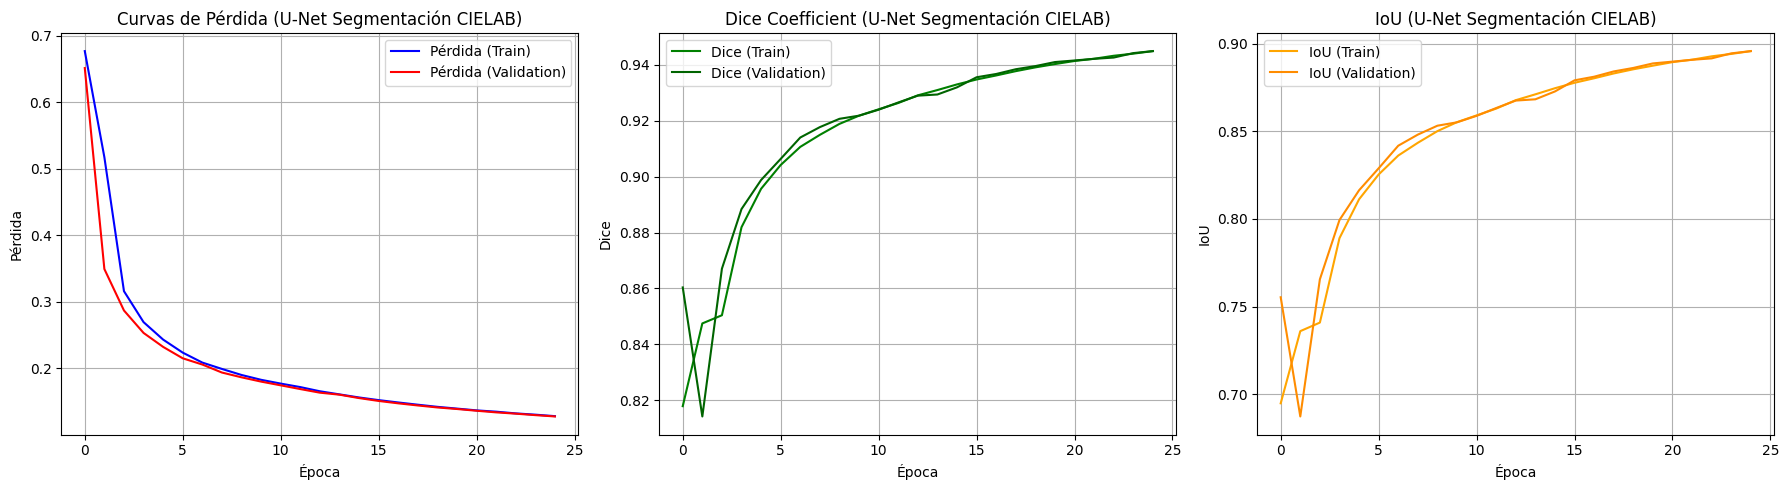

In [ ]:
# 🎯 VISUALIZACIÓN INMEDIATA DE U-NET
print("\n" + "="*70); print("GRÁFICAS DE ENTRENAMIENTO U-NET"); print("="*70)
plot_segmentation_history(unet_history_nested, '(U-Net Segmentación CIELAB)')

4. POST-PROCESAMIENTO: GENERACIÓN DE .NPY SEGMENTADOS (OPTIMIZADO)

In [ ]:
# --- InferenceDataset  ---
class InferenceDataset(Dataset):
    """Dataset optimizado para inferencia: Carga .npy Lab y devuelve datos para guardar."""
    def __init__(self, df, img_size):
        self.img_size = img_size
        self.original_paths = df['path'].tolist()
        self.npy_paths = df['npy_path'].tolist()
        self.classes = df['class'].tolist()
        self.transform_model = transforms.Compose([
            transforms.ToTensor(),
            LAB_NORMALIZE
        ])

    def __len__(self):
        return len(self.original_paths)

    def __getitem__(self, idx):
        npy_path = self.npy_paths[idx]
        original_path = self.original_paths[idx]
        img_class = self.classes[idx]
        try:
            img_np_lab = np.load(npy_path)
            img_tensor = self.transform_model(img_np_lab)
        except Exception as e:
            img_tensor = torch.zeros((CHANNELS, self.img_size[0], self.img_size[1]))
        try:
            img_np_lab_unnormalized = np.load(npy_path) # (H,W,C) [0-255]
        except Exception:
            img_np_lab_unnormalized = np.zeros((self.img_size[0], self.img_size[1], CHANNELS), dtype=np.uint8)
        return img_tensor, img_np_lab_unnormalized, original_path, img_class
# -------------------------------------------------------------------



In [ ]:
# Cargar el mejor modelo U-Net
unet_model = UNet(in_channels=CHANNELS, out_channels=1).to(DEVICE)
checkpoint = torch.load(unet_model_path, map_location=DEVICE)
unet_model.load_state_dict(checkpoint['model_state_dict'])
unet_model.eval()
print("\n✅ Modelo U-Net (CIELAB) cargado para segmentación.")

# Combinar todos los dataframes para inferencia
df_all_seg = pd.concat([df_train_valid, df_val_valid, df_test_valid]).drop_duplicates(subset=['path']).reset_index(drop=True)

INFERENCE_BATCH_SIZE = BATCH_SIZE_CNN
inference_dataset = InferenceDataset(df_all_seg, IMG_SIZE)
inference_loader = DataLoader(
    inference_dataset, batch_size=INFERENCE_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"\nGenerando archivos .npy segmentados (Inferencia por Lotes, BS={INFERENCE_BATCH_SIZE})...")
start_time = time.time()
path_map = {}

with torch.no_grad():
    for img_tensors, img_lab_unnormalized, img_paths, img_classes in tqdm(inference_loader, desc="Segmentando Lotes"):
        img_tensors = img_tensors.to(DEVICE)
        with autocast():
            predicted_masks_tensor = unet_model(img_tensors)
            predicted_masks_tensor = (torch.sigmoid(predicted_masks_tensor) > 0.5).float() #
        masks_batch_np = predicted_masks_tensor.cpu().numpy().transpose(0, 2, 3, 1) # [B, H, W, 1]
        img_lab_batch_np = img_lab_unnormalized.numpy() # [B, H, W, 3] (Lab uint8)

        for i in range(len(img_paths)):
            img_path = img_paths[i]; img_class = img_classes[i]
            img_lab_np = img_lab_batch_np[i]
            mask_np = masks_batch_np[i]

            segmented_lab_np = (img_lab_np * mask_np).astype(np.uint8)

            output_class_dir = os.path.join(SEG_LAB_NPY_DIR, img_class)
            os.makedirs(output_class_dir, exist_ok=True)

            img_name_seg = os.path.splitext(os.path.basename(img_path))[0] + '.npy'
            output_seg_path = os.path.join(output_class_dir, img_name_seg)

            np.save(output_seg_path, segmented_lab_np)
            path_map[img_path] = output_seg_path

print(f"--- Imágenes .npy segmentadas generadas en {time.time() - start_time:.2f} segundos ---")
# -----------------------------------------------------------




✅ Modelo U-Net (CIELAB) cargado para segmentación.

Generando archivos .npy segmentados (Inferencia por Lotes, BS=32)...


Segmentando Lotes:   0%|          | 0/79 [00:00<?, ?it/s]/tmp/ipykernel_37/2366306323.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Segmentando Lotes: 100%|██████████| 79/79 [00:02<00:00, 26.98it/s]

--- Imágenes .npy segmentadas generadas en 2.93 segundos ---


In [ ]:
# --- Preparar DataFrames (Optimizado) ---
print("Mapeando rutas .npy segmentadas a DataFrames...")
df_all_seg['segmented_npy_path'] = df_all_seg['path'].map(path_map)
df_all_seg['original_npy_path'] = df_all_seg['path'].apply(get_npy_path)

train_paths = set(df_train_valid['path'])
val_paths = set(df_val_valid['path'])
test_paths = set(df_test_valid['path'])

df_train_seg = df_all_seg[df_all_seg['path'].isin(train_paths)].copy()
df_val_seg = df_all_seg[df_all_seg['path'].isin(val_paths)].copy()
df_test_seg = df_all_seg[df_all_seg['path'].isin(test_paths)].copy()

df_train_seg['label'] = df_train_seg['class'].map(class_to_idx)
df_val_seg['label'] = df_val_seg['class'].map(class_to_idx)
df_test_seg['label'] = df_test_seg['class'].map(class_to_idx)

print("✅ DataFrames de clasificación listos (apuntando a .npy).")

Mapeando rutas .npy segmentadas a DataFrames...
✅ DataFrames de clasificación listos (apuntando a .npy).


5. CLASIFICACIÓN (sobre CIELAB) (OPTIMIZADO con .npy y AMP)

In [ ]:
# --- Transformaciones para Tensores (leídos desde .npy) ---
# Se aplica a Tensores (C,H,W) [0,1]
TRAIN_TRANSFORMS_CLS = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    LAB_NORMALIZE
])

VAL_TRANSFORMS_CLS = transforms.Compose([
    LAB_NORMALIZE
])
# ----------------------------------------------------------------

# --- Dataset de Clasificación (carga .npy) ---
class CoffeeClsDataset(Dataset):
    """Dataset para la CNN (optimizado, carga .npy)"""
    def __init__(self, df, use_segmented, transform):
        self.df = df.dropna(subset=['label', 'original_npy_path'])
        if use_segmented:
            self.df = self.df.dropna(subset=['segmented_npy_path'])
            self.path_list = self.df['segmented_npy_path'].tolist()
        else:
            self.path_list = self.df['original_npy_path'].tolist()
        self.labels = self.df['label'].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.path_list)

    def __getitem__(self, idx):
        img_path = self.path_list[idx]
        label = self.labels[idx]
        try:
            img_np = np.load(img_path)
            image_tensor = F.to_tensor(img_np)
        except Exception as e:
            image_tensor = torch.zeros((CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))
        image_tensor = self.transform(image_tensor)
        return image_tensor, label
# -----------------------------------------------------------------

# --- DataLoaders ---
print(f"\nCreando DataLoaders de Clasificación OPTIMIZADOS (CIELAB): Batch Size={BATCH_SIZE_CNN}, Workers={NUM_WORKERS}")
train_loader_seg = DataLoader(
    CoffeeClsDataset(df_train_seg, True, TRAIN_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader_seg = DataLoader(
    CoffeeClsDataset(df_val_seg, True, VAL_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
train_loader_orig = DataLoader(
    CoffeeClsDataset(df_train_seg, False, TRAIN_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader_orig = DataLoader(
    CoffeeClsDataset(df_val_seg, False, VAL_TRANSFORMS_CLS),
    batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
# -----------------------------------------------------------------

# --- Función 'Objective' de Optuna ---
def objective_cnn(trial, train_loader, val_loader):
    """
    Función objetivo para Optuna. Entrena un modelo con los hiperparámetros
    sugeridos por 'trial' y devuelve la mejor métrica.
    """

    # 1. Definir el espacio de búsqueda de hiperparámetros
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.6)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)

    # 2. Configurar el modelo y optimizador con los parámetros del 'trial'
    model = SimpleCNN(num_classes=NUM_CLASSES, dropout_rate=dropout_rate).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()

    best_val_kappa = -1.0
    patience_counter = 0

    # 3. Bucle de entrenamiento
    for epoch in range(EPOCHS_CNN):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # Bucle de validación
        model.eval()
        all_preds_epoch, all_labels_epoch = [], []
        current_val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast(device_type=DEVICE.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                current_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                all_preds_epoch.extend(predicted.cpu().numpy())
                all_labels_epoch.extend(labels.cpu().numpy())

        # Calcular métricas de la época
        epoch_val_loss = current_val_loss / len(val_loader.dataset)
        epoch_val_kappa = cohen_kappa_score(all_labels_epoch, all_preds_epoch)

        # Guardar el mejor Kappa
        if epoch_val_kappa > best_val_kappa:
            best_val_kappa = epoch_val_kappa
            patience_counter = 0
        else:
            patience_counter += 1

        # Early Stopping
        if patience_counter >= CNN_EARLY_STOP_PATIENCE:
            break

    # 4. Devolver la métrica que Optuna debe optimizar
    return best_val_kappa
# -----------------------------------------------------------------

# --- Ejecutar los estudios de Optuna ---
print("\n" + "="*70); print("INICIANDO OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA)"); print("="*70)

# --- Estudio 1: Modelo Segmentado ---
print(f"Optimizando para el Modelo SEGMENTADO ({N_TRIALS_OPTUNA} pruebas)...")
study_seg = optuna.create_study(direction="maximize")
study_seg.optimize(
    lambda trial: objective_cnn(trial, train_loader_seg, val_loader_seg),
    n_trials=N_TRIALS_OPTUNA,
    show_progress_bar=True
)
print("Optimización SEGMENTADA completada.")
print(f"Mejor Kappa (Segmentado): {study_seg.best_value:.4f}")
print(f"Mejores Hiperparámetros: {study_seg.best_params}")

# --- Estudio 2: Modelo Original (Base) ---
print("\n" + "="*50)
print(f"Optimizando para el Modelo ORIGINAL ({N_TRIALS_OPTUNA} pruebas)...")
study_orig = optuna.create_study(direction="maximize")
study_orig.optimize(
    lambda trial: objective_cnn(trial, train_loader_orig, val_loader_orig),
    n_trials=N_TRIALS_OPTUNA,
    show_progress_bar=True
)
print("Optimización ORIGINAL completada.")
print(f"Mejor Kappa (Original): {study_orig.best_value:.4f}")
print(f"Mejores Hiperparámetros: {study_orig.best_params}")
# -----------------------------------------------------------------

[I 2025-10-28 06:33:10,968] A new study created in memory with name: no-name-ceb135ed-be5c-49d4-a755-8593e67ab1e0



Creando DataLoaders de Clasificación OPTIMIZADOS (CIELAB): Batch Size=32, Workers=4

INICIANDO OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA)
Optimizando para el Modelo SEGMENTADO (30 pruebas)...


  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_37/1462992598.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


[I 2025-10-28 06:34:27,778] Trial 0 finished with value: 0.9900201191211331 and parameters: {'lr': 0.0001142139579405677, 'dropout_rate': 0.491180354517162, 'weight_decay': 1.990719041928033e-06}. Best is trial 0 with value: 0.9900201191211331.


...

[I 2025-10-28 07:41:05,324] Trial 27 finished with value: 0.9975049925050175 and parameters: {'lr': 0.0003516399696136279, 'dropout_rate': 0.38387099700739596, 'weight_decay': 4.75526872103088e-05}. Best is trial 13 with value: 0.9975049925050175.


/tmp/ipykernel_37/1462992598.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


[I 2025-10-28 07:42:44,324] Trial 28 finished with value: 0.9950100098604595 and parameters: {'lr': 6.29013116462798e-05, 'dropout_rate': 0.32434793935298756, 'weight_decay': 9.976536099157359e-05}. Best is trial 13 with value: 0.9975049925050175.


/tmp/ipykernel_37/1462992598.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


[I 2025-10-28 07:44:01,823] Trial 29 finished with value: 0.9950100098604595 and parameters: {'lr': 0.00011141438870869406, 'dropout_rate': 0.35729391501941343, 'weight_decay': 3.768697439132987e-06}. Best is trial 13 with value: 0.9975049925050175.
Optimización ORIGINAL completada.
Mejor Kappa (Original): 0.9975
Mejores Hiperparámetros: {'lr': 0.0001752980274408874, 'dropout_rate': 0.44447200469914827, 'weight_decay': 4.900287574383751e-06}


6. COMPARACIÓN FINAL


INICIANDO ENTRENAMIENTO FINAL (CON PARÁMETROS OPTIMIZADOS)

--- INICIANDO ENTRENAMIENTO COMPLETO: Segmented CNN (OPTIMIZADO) (con AMP) ---
Usando parámetros optimizados: {'lr': 0.0005875190642086289, 'dropout_rate': 0.5938792749809161, 'weight_decay': 5.940665472293219e-05}


/tmp/ipykernel_37/2203433099.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/50: Train Loss: 1.2525 (V:0.7486) | Train Acc: 0.4128 (V:0.8204)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_segmented_cnn_(optimizado)_best.pth (Val Loss: 0.7486)


Epoch 2/50: Train Loss: 0.6580 (V:0.4198) | Train Acc: 0.6667 (V:0.9800)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_segmented_cnn_(optimizado)_best.pth (Val Loss: 0.4198)


Epoch 3/50: Train Loss: 0.4037 (V:0.2127) | Train Acc: 0.8302 (V:0.9880)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_segmented_cnn_(optimizado)_best.pth (Val Loss: 0.2127)


...

Epoch 32/50: Train Loss: 0.0396 (V:0.0131) | Train Acc: 0.9891 (V:0.9960)


Epoch 33/50: Train Loss: 0.0408 (V:0.0346) | Train Acc: 0.9863 (V:0.9900)


Epoch 34/50: Train Loss: 0.0455 (V:0.0131) | Train Acc: 0.9846 (V:0.9980)
  -> Early Stopping activado (paciencia=10)!


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
train_acc,▁▄▆▇▇▇████████████████████████████
train_loss,█▅▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▇████████████████████████████████
val_kappa,▁▇████████████████████████████████
val_loss,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,33
train_acc,0.98456
train_loss,0.04551
val_acc,0.998
val_kappa,0.9975



--- RESULTADOS FINALES PARA Segmented CNN (OPTIMIZADO) ---

REPORTE DE CLASIFICACIÓN (VALIDACIÓN):
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00       100
       Green       1.00      1.00      1.00       100
       Light       0.99      1.00      1.00       100
      Medium       1.00      0.99      1.00       101
  Overbaking       1.00      1.00      1.00       100

    accuracy                           1.00       501
   macro avg       1.00      1.00      1.00       501
weighted avg       1.00      1.00      1.00       501


COEFICIENTE KAPPA (VALIDACIÓN): 0.9975

MATRIZ DE CONFUSIÓN (VALIDACIÓN):
[[100   0   0   0   0]
 [  0 100   0   0   0]
 [  0   0 100   0   0]
 [  0   0   1 100   0]
 [  0   0   0   0 100]]


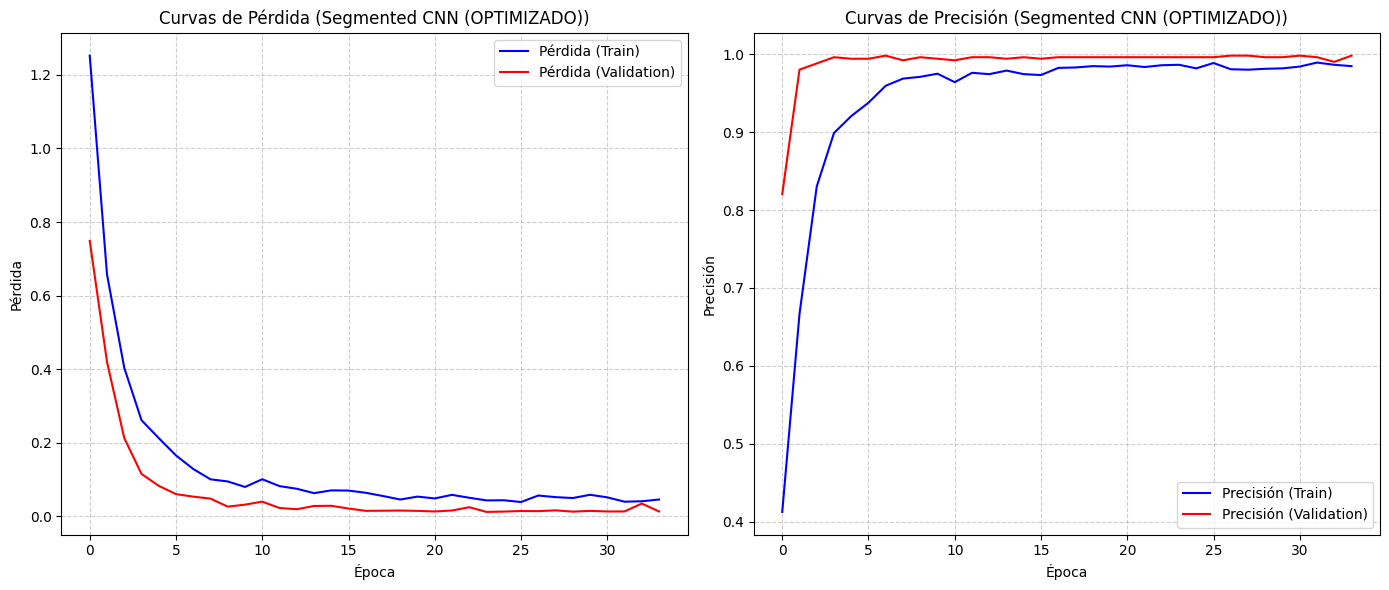


--- INICIANDO ENTRENAMIENTO COMPLETO: Original CNN (OPTIMIZADO) (con AMP) ---
Usando parámetros optimizados: {'lr': 0.0001752980274408874, 'dropout_rate': 0.44447200469914827, 'weight_decay': 4.900287574383751e-06}


/tmp/ipykernel_37/2203433099.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/50: Train Loss: 1.5435 (V:1.4101) | Train Acc: 0.3099 (V:0.4012)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_original_cnn_(optimizado)_best.pth (Val Loss: 1.4101)


Epoch 2/50: Train Loss: 1.2202 (V:0.9433) | Train Acc: 0.5449 (V:0.8723)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_original_cnn_(optimizado)_best.pth (Val Loss: 0.9433)


Epoch 3/50: Train Loss: 0.8926 (V:0.6930) | Train Acc: 0.6387 (V:0.7924)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_original_cnn_(optimizado)_best.pth (Val Loss: 0.6930)


...

Epoch 48/50: Train Loss: 0.0360 (V:0.0226) | Train Acc: 0.9926 (V:0.9940)


Epoch 49/50: Train Loss: 0.0353 (V:0.0184) | Train Acc: 0.9920 (V:0.9960)


Epoch 50/50: Train Loss: 0.0342 (V:0.0155) | Train Acc: 0.9909 (V:0.9960)
  -> Guardando nuevo mejor modelo CNN en /kaggle/working/output_data/cnn_original_cnn_(optimizado)_best.pth (Val Loss: 0.0155)


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▃▄▅▆▇▇█████████████████████████████████
train_loss,█▇▅▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▇▆█▇███████████████████████████████████
val_kappa,▁▇▆█▇███████████████████████████████████
val_loss,█▆▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,49
train_acc,0.99085
train_loss,0.03423
val_acc,0.99601
val_kappa,0.99501



--- RESULTADOS FINALES PARA Original CNN (OPTIMIZADO) ---

REPORTE DE CLASIFICACIÓN (VALIDACIÓN):
              precision    recall  f1-score   support

        Dark       1.00      1.00      1.00       100
       Green       1.00      1.00      1.00       100
       Light       0.98      1.00      0.99       100
      Medium       1.00      0.98      0.99       101
  Overbaking       1.00      1.00      1.00       100

    accuracy                           1.00       501
   macro avg       1.00      1.00      1.00       501
weighted avg       1.00      1.00      1.00       501


COEFICIENTE KAPPA (VALIDACIÓN): 0.9950

MATRIZ DE CONFUSIÓN (VALIDACIÓN):
[[100   0   0   0   0]
 [  0 100   0   0   0]
 [  0   0 100   0   0]
 [  0   0   2  99   0]
 [  0   0   0   0 100]]


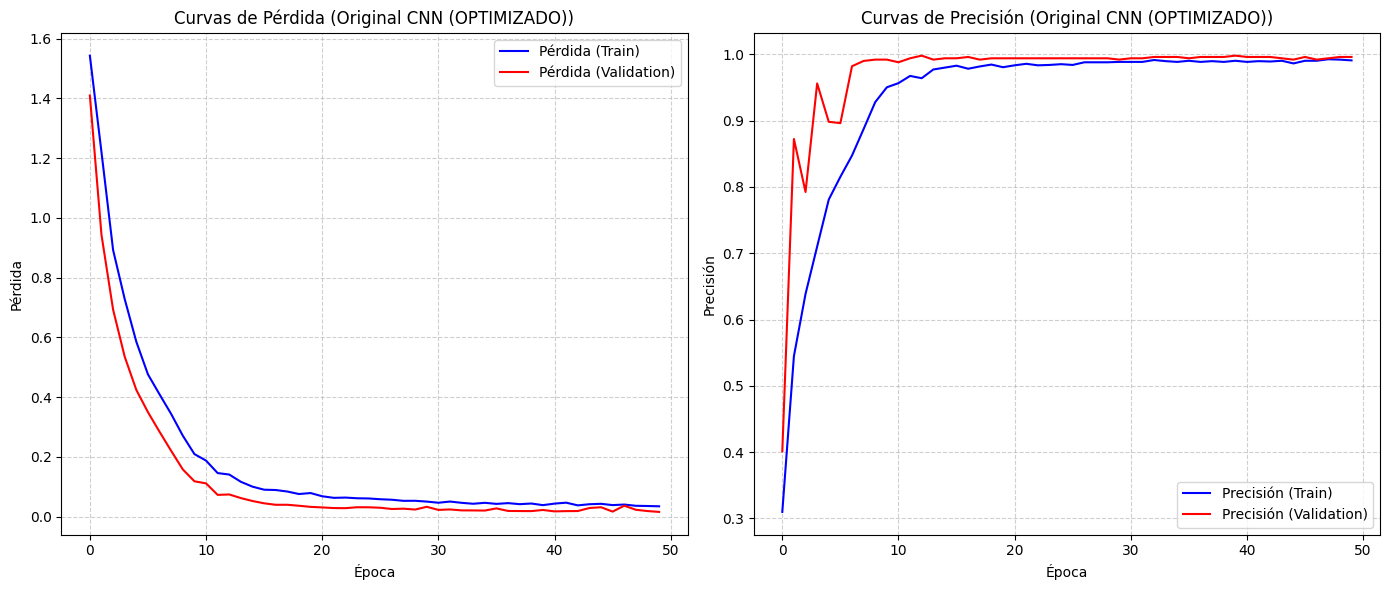


COMPARACIÓN FINAL DE MÉTRICAS DE VALIDACIÓN (OPTIMIZADO)


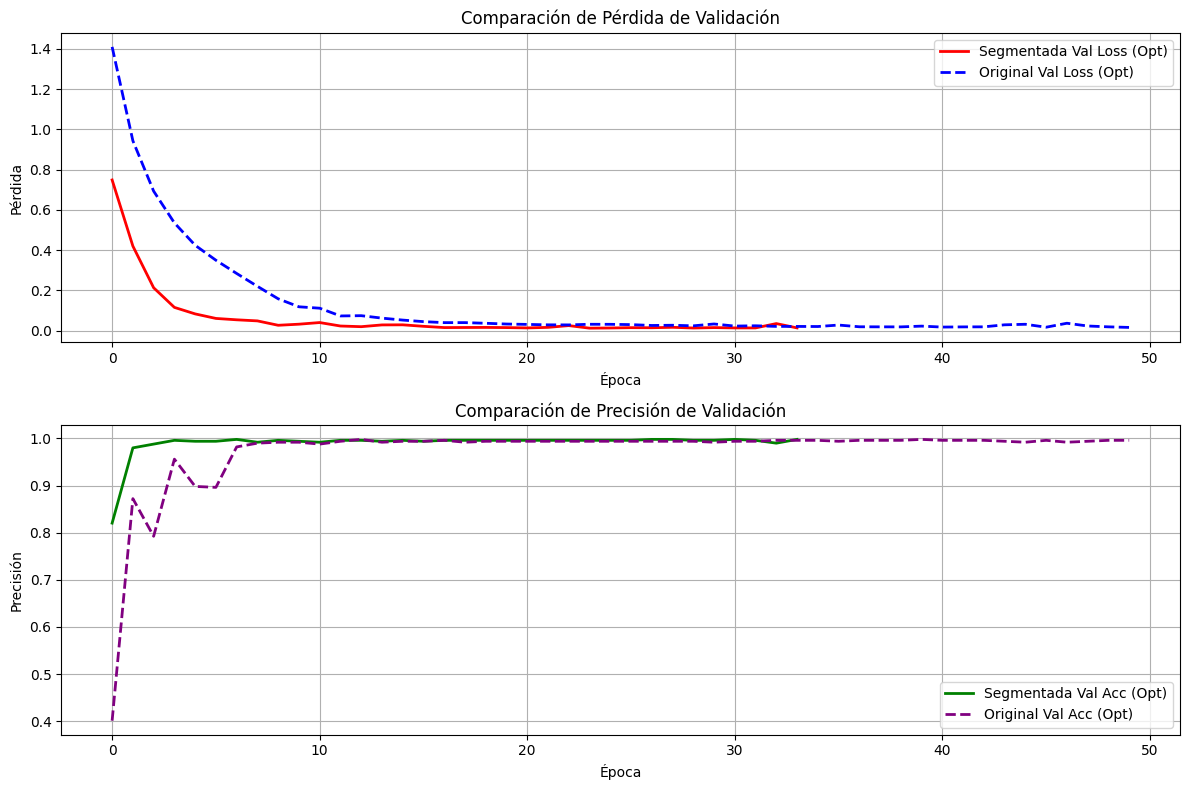


🎉 FIN DEL PIPELINE CON OPTIMIZACIÓN OPTUNA. 🎉


In [ ]:
print("\n" + "="*70); print("INICIANDO ENTRENAMIENTO FINAL (CON PARÁMETROS OPTIMIZADOS)"); print("="*70)

# --- Funciones de Visualización y Evaluación de Clasificación (sin cambios) ---
def plot_training_history_cls(history, title_suffix):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Pérdida (Train)', color='blue')
    plt.plot(history['val_loss'], label='Pérdida (Validation)', color='red')
    plt.title(f'Curvas de Pérdida {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Precisión (Train)', color='blue')
    plt.plot(history['val_accuracy'], label='Precisión (Validation)', color='red')
    plt.title(f'Curvas de Precisión {title_suffix}'); plt.xlabel('Época'); plt.ylabel('Precisión'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

def evaluate_and_plot_cls(model_name, history, labels_val, preds_val, idx_to_class_map, num_classes_val):
    print(f"\n--- RESULTADOS FINALES PARA {model_name} ---")
    target_names = [idx_to_class_map[i] for i in range(num_classes_val)]
    print("\nREPORTE DE CLASIFICACIÓN (VALIDACIÓN):")
    print(classification_report(labels_val, preds_val, target_names=target_names))
    kappa = cohen_kappa_score(labels_val, preds_val)
    print(f"\nCOEFICIENTE KAPPA (VALIDACIÓN): {kappa:.4f}")
    print("\nMATRIZ DE CONFUSIÓN (VALIDACIÓN):")
    print(confusion_matrix(labels_val, preds_val))
    plot_training_history_cls(history, f'({model_name})')

# --- ¡NUEVO! Bucle de Entrenamiento Final (Usa parámetros optimizados y W&B) ---
def run_final_training(model_name, train_loader, val_loader, params,
                       epochs=EPOCHS_CNN, patience=CNN_EARLY_STOP_PATIENCE,
                       visualize=False, idx_to_class_map=None, num_classes_val=None):

    print(f"\n--- INICIANDO ENTRENAMIENTO COMPLETO: {model_name} (con AMP) ---")
    print(f"Usando parámetros optimizados: {params}")

    # 1. Configurar W&B para este 'run' final
    WANDB_PROJECT_CNN = "tesis-cafe-clasificacion"

    # Definir una ruta de log separada para la CNN
    KAGGLE_WANDB_DIR_CNN = os.path.join(OUTPUT_DIR, 'wandb_logs_cnn')
    os.makedirs(KAGGLE_WANDB_DIR_CNN, exist_ok=True)
    os.environ['WANDB_DIR'] = KAGGLE_WANDB_DIR_CNN

    wandb.init(
        project=WANDB_PROJECT_CNN,
        name=f"FINAL_optuna_{model_name}_v2",
        config=params,
        reinit=True
    )
    # -----------------------------------------------------------------

    # 2. Configurar modelo y optimizador con parámetros de Optuna
    model = SimpleCNN(num_classes=NUM_CLASSES, dropout_rate=params['dropout_rate']).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()
    model_path = os.path.join(OUTPUT_DIR, f'cnn_{model_name.lower().replace(" ", "_")}_best.pth')

    history = defaultdict(list)
    best_val_loss, patience_counter = float('inf'), 0
    all_preds, all_labels = [], []

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total_samples = 0.0, 0, 0
        loop_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train CLS]", leave=False)

        for images, labels in loop_train:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast(device_type=DEVICE.type):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * images.size(0)
            with torch.no_grad():
                _, predicted = torch.max(outputs, 1); train_correct += (predicted == labels).sum().item(); total_samples += images.size(0)
                loop_train.set_postfix(loss=loss.item(), acc=(predicted == labels).sum().item() / images.size(0))

        epoch_train_loss = train_loss / total_samples
        epoch_train_accuracy = train_correct / total_samples

        model.eval()
        val_loss, val_correct, total_val_samples = 0.0, 0, 0
        all_preds_epoch, all_labels_epoch = [], []
        loop_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val CLS]", leave=False)

        with torch.no_grad():
            for images, labels in loop_val:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                with autocast(device_type=DEVICE.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1); val_correct += (predicted == labels).sum().item(); total_val_samples += images.size(0)
                all_preds_epoch.extend(predicted.cpu().numpy()); all_labels_epoch.extend(labels.cpu().numpy())
                loop_val.set_postfix(loss=loss.item(), acc=(predicted == labels).sum().item() / images.size(0))

        epoch_val_loss = val_loss / total_val_samples
        epoch_val_accuracy = val_correct / total_val_samples
        all_preds = all_preds_epoch; all_labels = all_labels_epoch

        print(f'Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f} (V:{epoch_val_loss:.4f}) | Train Acc: {epoch_train_accuracy:.4f} (V:{epoch_val_accuracy:.4f})')

        # Loggear a W&B
        wandb.log({
            "train_loss": epoch_train_loss, "val_loss": epoch_val_loss,
            "train_acc": epoch_train_accuracy, "val_acc": epoch_val_accuracy,
            "val_kappa": cohen_kappa_score(all_labels, all_preds),
            "epoch": epoch
        })

        history['loss'].append(epoch_train_loss); history['val_loss'].append(epoch_val_loss)
        history['accuracy'].append(epoch_train_accuracy); history['val_accuracy'].append(epoch_val_accuracy)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            save_checkpoint_cnn(model, model_path, best_val_loss)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> Early Stopping activado (paciencia={patience})!")
                break

    checkpoint = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    wandb.finish() # Finalizar el 'run' de W&B

    if visualize:
         evaluate_and_plot_cls(model_name, history, all_labels, all_preds, idx_to_class, NUM_CLASSES)
    return model, history, all_labels, all_preds
# -----------------------------------------------------------------

# --- Entrenar Experimentos Finales y Visualizar ---

# 1. Obtener los mejores parámetros de los estudios
best_params_seg = study_seg.best_params
best_params_orig = study_orig.best_params

# 2. Entrenar y Visualizar el Modelo Segmentado
model_seg, history_seg, labels_val_seg, preds_val_seg = run_final_training(
    'Segmented CNN (OPTIMIZADO)',
    train_loader_seg, val_loader_seg,
    params=best_params_seg,
    epochs=EPOCHS_CNN, patience=CNN_EARLY_STOP_PATIENCE,
    visualize=True, idx_to_class_map=idx_to_class, num_classes_val=NUM_CLASSES
)

# 3. Entrenar y Visualizar el Modelo Original
model_orig, history_orig, labels_val_orig, preds_val_orig = run_final_training(
    'Original CNN (OPTIMIZADO)',
    train_loader_orig, val_loader_orig,
    params=best_params_orig,
    epochs=EPOCHS_CNN, patience=CNN_EARLY_STOP_PATIENCE,
    visualize=True, idx_to_class_map=idx_to_class, num_classes_val=NUM_CLASSES
)

# --- Comparación Final (Gráficas) ---
print("\n" + "="*70); print("COMPARACIÓN FINAL DE MÉTRICAS DE VALIDACIÓN (OPTIMIZADO)"); print("="*70)
plt.figure(figsize=(12, 8))

# Pérdida
plt.subplot(2, 1, 1)
plt.plot(history_seg['val_loss'], label='Segmentada Val Loss (Opt)', linestyle='-', color='red', linewidth=2)
plt.plot(history_orig['val_loss'], label='Original Val Loss (Opt)', linestyle='--', color='blue', linewidth=2)
plt.title('Comparación de Pérdida de Validación')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(True)

# Precisión
plt.subplot(2, 1, 2)
plt.plot(history_seg['val_accuracy'], label='Segmentada Val Acc (Opt)', linestyle='-', color='green', linewidth=2)
plt.plot(history_orig['val_accuracy'], label='Original Val Acc (Opt)', linestyle='--', color='purple', linewidth=2)
plt.title('Comparación de Precisión de Validación')
plt.xlabel('Época'); plt.ylabel('Precisión'); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()

print("\n🎉 FIN DEL PIPELINE CON OPTIMIZACIÓN OPTUNA. 🎉")

7. SECCIÓN: INFERENCIA COMPARATIVA (CIELAB) (OPTIMIZADO)


INICIANDO SECCIÓN DE INFERENCIA COMPARATIVA (CIELAB)
Modelos ya en memoria y en modo eval().
✅ Modelos U-Net, CNN Segmentada y CNN Original listos en cuda.

Ejecutando inferencia comparativa en una imagen del set de Test...

Imagen de prueba: IMG_3029.JPG
Clase Real:       Dark
--- RESULTADOS DE INFERENCIA (CIELAB) [OPTIMIZADO] ---
Pred. (Segmentada): Medium (Confianza: 0.98)
Pred. (Original):   Dark (Confianza: 1.00)


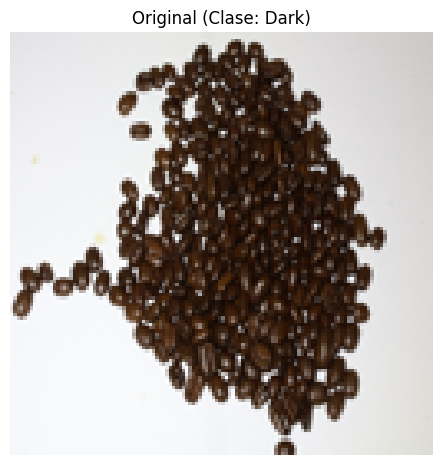


✅ Sección de Inferencia Comparativa (CIELAB) completada.

🎉 FIN DEL PIPELINE OPTIMIZADO. 🎉


In [ ]:
print("\n" + "="*70); print("INICIANDO SECCIÓN DE INFERENCIA COMPARATIVA (CIELAB)"); print("="*70)

# --- 1. Cargar los modelos ---
try:
    unet_model.eval(); model_seg.eval(); model_orig.eval()
    print("Modelos ya en memoria y en modo eval().")
except NameError:
    print("Cargando modelos desde archivo...")
    # Cargar U-Net
    unet_model_path = os.path.join(OUTPUT_DIR, 'unet_segmentation_model_best.pth')
    unet_model = UNet(in_channels=CHANNELS, out_channels=1).to(DEVICE)
    checkpoint_unet = torch.load(unet_model_path, map_location=DEVICE)
    unet_model.load_state_dict(checkpoint_unet['model_state_dict'])
    unet_model.eval()

    # Cargar CNN Segmentada
    cnn_seg_path = os.path.join(OUTPUT_DIR, 'cnn_segmented_cnn_(u-net)_best.pth')
    model_seg = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_cnn = torch.load(cnn_seg_path, map_location=DEVICE)
    model_seg.load_state_dict(checkpoint_cnn['model_state_dict'])
    model_seg.eval()

    # Cargar CNN Original
    cnn_orig_path = os.path.join(OUTPUT_DIR, 'cnn_original_cnn_(baseline)_best.pth')
    model_orig = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    checkpoint_orig = torch.load(cnn_orig_path, map_location=DEVICE)
    model_orig.load_state_dict(checkpoint_orig['model_state_dict'])
    model_orig.eval()

print(f"✅ Modelos U-Net, CNN Segmentada y CNN Original listos en {DEVICE}.")

# --- ¡MODIFICADO! Transformación de Inferencia (desde .npy) ---
TRANSFORM_INFERENCE = transforms.Compose([
    transforms.ToTensor(), # (H,W,C) [0, 255] -> (C,H,W) [0, 1]
    LAB_NORMALIZE          # Normalizar [0, 1] -> [-1, 1]
])
# ---------------------------------------------------------

# --- 2. Funciones de Inferencia (OPTIMIZADAS) ---

def predict_pipeline_segmented(original_img_path, unet_model, cnn_model, device, img_size):
    """
    Pipeline OPTIMIZADO (Inferencia por imagen):
    Carga .npy(Lab) -> U-Net(Lab) -> Máscara(Tensor) -> CNN(Lab) -> Predicción
    """
    try:
        # 1. Cargar el .NPY Lab pre-procesado
        npy_path = get_npy_path(original_img_path) # (Función de 2B)
        img_np_lab = np.load(npy_path)

        # 2. Preparar tensor para U-Net
        image_tensor_unet = TRANSFORM_INFERENCE(img_np_lab).unsqueeze(0).to(device)

    except Exception as e:
        print(f"Error al cargar el .npy: {e}"); return None, None, None

    with torch.no_grad():
        with autocast(device_type=DEVICE.type):
            # --- Paso 1: Segmentación (Tensor) ---
            mask_pred_tensor = unet_model(image_tensor_unet) # (1, 1, H, W)
            mask_binary = (mask_pred_tensor > 0.5).float()

            # --- Paso 2: Aplicar Máscara (Tensor) ---
            image_tensor_cnn = image_tensor_unet * mask_binary # (1, 3, H, W)

            # --- Paso 3: Clasificación (Tensor) ---
            outputs = cnn_model(image_tensor_cnn)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

    pred_class_idx = predicted_idx.item()
    pred_class_name = idx_to_class.get(pred_class_idx, "Desconocido")
    pred_confidence = confidence.item()

    # --- Paso 4: Visualización  ---
    try:
        image_pil = Image.open(original_img_path).convert("RGB").resize(img_size, Image.BILINEAR)
        image_cv_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
        mask_np = mask_binary.squeeze().cpu().numpy().astype(np.uint8) * 255
        mask_3_channels = cv2.cvtColor(mask_np, cv2.COLOR_GRAY2BGR)
        segmented_img_cv = cv2.bitwise_and(image_cv_bgr, mask_3_channels)
        segmented_img_pil = Image.fromarray(cv2.cvtColor(segmented_img_cv, cv2.COLOR_BGR_RGB))
    except Exception as e:
        segmented_img_pil = None # Fallback

    return pred_class_name, pred_confidence, segmented_img_pil

def predict_pipeline_original(original_img_path, cnn_model, device):
    """
    Pipeline OPTIMIZADO (Inferencia por imagen):
    Carga .npy(Lab) -> CNN(Lab) -> Predicción
    """
    try:
        # 1. Cargar el .NPY Lab pre-procesado (RÁPIDO)
        npy_path = get_npy_path(original_img_path)
        img_np_lab = np.load(npy_path)

        # 2. Preparar tensor para CNN
        image_tensor_cnn = TRANSFORM_INFERENCE(img_np_lab).unsqueeze(0).to(device)

    except Exception as e:
        print(f"Error al cargar el .npy: {e}"); return None, None

    with torch.no_grad():
        with autocast(device_type=DEVICE.type):
            # --- Paso 1: Clasificación ---
            outputs = cnn_model(image_tensor_cnn)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

    pred_class_idx = predicted_idx.item()
    pred_class_name = idx_to_class.get(pred_class_idx, "Desconocido")
    pred_confidence = confidence.item()

    return pred_class_name, pred_confidence
# -------------------------------------------------------------

# --- 3. Probar la inferencia comparativa ---
if not df_test_seg.empty:
    print("\nEjecutando inferencia comparativa en una imagen del set de Test...")

    sample_row = df_test_seg.sample(1).iloc[0]
    sample_path = sample_row['path'] # Ruta original .jpg
    actual_class = sample_row['class']

    print(f"\nImagen de prueba: {os.path.basename(sample_path)}")
    print(f"Clase Real:       {actual_class}")

    # --- Inferencia 1: Pipeline Segmentado (Lab) ---
    pred_seg_class, pred_seg_conf, segmented_image = predict_pipeline_segmented(
        sample_path, unet_model, model_seg, DEVICE, IMG_SIZE
    )

    # --- Inferencia 2: Pipeline Original (Lab) ---
    pred_orig_class, pred_orig_conf = predict_pipeline_original(
        sample_path, model_orig, DEVICE
    )

    print("--- RESULTADOS DE INFERENCIA (CIELAB) [OPTIMIZADO] ---")
    print(f"Pred. (Segmentada): {pred_seg_class} (Confianza: {pred_seg_conf:.2f})")
    print(f"Pred. (Original):   {pred_orig_class} (Confianza: {pred_orig_conf:.2f})")

    # Mostrar resultados visuales
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(sample_path).resize(IMG_SIZE))
    plt.title(f"Original (Clase: {actual_class})")
    plt.axis('off')

    if segmented_image:
        plt.subplot(1, 2, 2)
        plt.imshow(segmented_image)
        plt.title(f"Segmentada (Pred: {pred_seg_class})")
        plt.axis('off')

    plt.show()

else:
    print("\nNo se encontraron imágenes en 'df_test_seg' para la inferencia de prueba.")

print("\n✅ Sección de Inferencia Comparativa (CIELAB) completada.")
print("\n🎉 FIN DEL PIPELINE OPTIMIZADO. 🎉")

In [ ]:
import shutil

# Ruta a tu carpeta de salida
folder_to_zip = '/kaggle/working/output_data'

# Nombre del archivo zip de salida
zip_filename = '/kaggle/working/tesis_completa_salidas_v2'

print(f"Comprimiendo {folder_to_zip} en {zip_filename}.zip ...")

# Crear el archivo zip
shutil.make_archive(zip_filename, 'zip', folder_to_zip)

print(f"¡Compresión completada! Puedes descargar '{zip_filename}.zip' desde el panel de 'Data' -> 'Output'.")

Comprimiendo /kaggle/working/output_data en /kaggle/working/tesis_completa_salidas_v2.zip ...
¡Compresión completada! Puedes descargar '/kaggle/working/tesis_completa_salidas_v2.zip' desde el panel de 'Data' -> 'Output'.
